# Galactic propagation of highly-energetic gamma rays

Through this example, one can test the propagation of galactic gamma rays from point-like sources, also including the electromagnetic processes with the 3D spatial models of the interstellar radiation field (ISRF) and the cosmic microwave background (CMB). More details on this new code implementation at https://arxiv.org/abs/2507.11475. Interaction rate and density tables needs to be downloaded from https://saco.csic.es/s/2FD4AespQ4TQd57?opendetails= and then properly added to the CRPropa data path.

In [9]:
from crpropa import *
import numpy as np
import matplotlib.pyplot as plt

# gamma-ray source cartesian position (kpc).
x = -7.
y = 6.8
z = 0.

# source distance from the Earth, placed at (-8.5, 0, 0) kpc in the JF12 galactic magnetic field model. 
D = np.sqrt((x - (-8.5))**2. + y * y + z * z)

# aperture angle of the source (rad).
Acon = 0.1

# radius of the spherical observer placed at the Earth position (kpc).
Orad = np.tan(Acon) * D 

# number of gamma rays injected by the source.
nEvents = 100000

# gamma-ray source injection spectrum (eV).
Emin = 1e12 
Emax = 1e15 
specIndex = -1

# particles track
photons = True
electrons = True
thinning = 1.
minEnergy = Emin #eV

# simulation steps. 
minStep = 1e-3 #kpc
maxStep = 1e-2 #kpc
tol = 1e-4

# magnetic field setup.
B = JF12Field()
randomSeed = 691342
B.randomStriated(randomSeed)
B.randomTurbulent(randomSeed)

# output coordinates
path = "..."
outputName = 'galactic_propagation_3Disrf.txt'
outputName_inj = 'galactic_propagation_3Disrf_inj.txt'

# photon backgrounds:
# homogeneuos, 
cmb = CMB()
ebl = IRB_Gilmore12()

# position dependent. (Sphere to load only the ISRF nodes close to observer and the source.)
isrf = ISRF_Freudenreich98(Sphere(Vector3d(x, y, z) * kpc, D * kpc + 1 * kpc))

Photon tables not found in /home/jnb/Programs/anaconda3/envs/exampleTest/share/crpropa/Scaling/ISRF_Freudenreich98/photonEnergy/


## Plot the background densities

A plot to check the ISRF densities at different positions in the Galaxy (cartesian coordinates). The code takes the ISRF density as the one of the closest node to each position. These are compared to the CMB and extragalactic background light (EBL) homogeneous fields.  

<>:36: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:36: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_185873/2374029892.py:36: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.xlabel("$\epsilon$ [eV]")


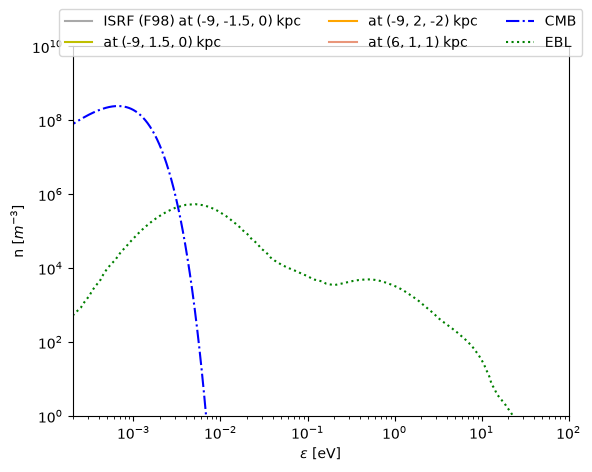

In [10]:
# positions where to compute the ISRF densities. 
pos = Vector3d(-9, -1.5, 0) * kpc
pos1 = Vector3d(-9, 1.5, 0) * kpc
pos2 = Vector3d(-9, 2, -2) * kpc
pos3 = Vector3d(6, 1., 1.) * kpc

eps = np.logspace(-4, 5, 1000)

y0 = np.zeros(len(eps))
y1 = np.zeros(len(eps))
y2 = np.zeros(len(eps))
y3 = np.zeros(len(eps))

ycmb = np.zeros(len(eps))
yebl = np.zeros(len(eps))


for i in range(len(eps)):
    y0[i] = isrf.getPhotonDensity(eps[i] * eV, 0., pos)
    y1[i] = isrf.getPhotonDensity(eps[i] * eV, 0., pos1)
    y2[i] = isrf.getPhotonDensity(eps[i] * eV, 0., pos2)
    y3[i] = isrf.getPhotonDensity(eps[i] * eV, 0., pos3)
    ycmb[i] = cmb.getPhotonDensity(eps[i] * eV, 0., pos)
    yebl[i] = ebl.getPhotonDensity(eps[i] * eV, 0., pos)
    
plt.plot(eps, y0, label = "ISRF (F98) at (-9, -1.5, 0) kpc", c='darkgrey')
plt.plot(eps, y1, label = "at (-9, 1.5, 0) kpc", c='y')
plt.plot(eps, y2, label = "at (-9, 2, -2) kpc", c='orange')
plt.plot(eps, y3, label = "at (6, 1, 1) kpc", c='darksalmon')
plt.plot(eps, ycmb, label = "CMB", c='b', linestyle='-.')
plt.plot(eps, yebl, label = "EBL", c='g', linestyle=':')
plt.loglog()
plt.ylim(1e0,1e10)
plt.xlim(2e-4,1e2)
plt.legend(ncol = 3, loc= "upper center", bbox_to_anchor=(0.5, 1.12))
plt.xlabel("$\epsilon$ [eV]")
plt.ylabel(r"n [$m^{-3}$]")
plt.savefig(path + "bkgDensities.png")
plt.show()

## Defining the galactic gamma-ray source and the observer

The source points towards the spherical osberver at the Earth. An second tiny spherical observer is placed at the source position to get the injection spectrum. 

In [11]:
# versor pointing to the observer.
vx = -(x + 8.5)
vy = -y
vz = -z
v = Vector3d(vx, vy, vz)
v /= v.getR() 

source = Source()
source.add(SourcePosition(Vector3d(x, y, z) * kpc))
source.add(SourceEmissionCone(v, Acon))
source.add(SourcePowerLawSpectrum(Emin * eV, Emax * eV, specIndex))
source.add(SourceParticleType(22))

# observer surrounding the source.
obs1 = Observer()
obs1.add(ObserverSurface(Sphere(Vector3d(x, y, z) * kpc, 1e-6 * kpc)))
output1 = TextOutput(path + outputName_inj, Output.Everything) 
output1.enable(Output.WeightColumn)
output1.enable(Output.CandidateTagColumn)
output1.setEnergyScale(EeV)
obs1.onDetection(output1)
obs1.setDeactivateOnDetection(False)


# observer at the Earth. 
obs = Observer()
obs.add(ObserverSurface(Sphere(Vector3d(-8.5, 0., 0.) * kpc, Orad * kpc)))
output = TextOutput(path + outputName, Output.Everything)
output.enable(Output.WeightColumn)
output.enable(Output.CandidateTagColumn)
output.setEnergyScale(EeV)
obs.onDetection(output)
obs.setDeactivateOnDetection(True)

## Running the simulation

The full development of the electromagnetic cascade is simulated, considering also the deflection of the electrons due to the galactic magnetic field. The processes at play are pair production and inverse Compton scatterings, both on the CMB and the ISRF.

The ISRF interaction tables are restricted to the ones in the region of interest, i.e. the space between the observer and the source. 

In [ ]:
# module setup
sim = ModuleList()
sim.add(PropagationBP(B, tol, minStep * kpc, maxStep * kpc))

sim.add(EMPairProduction(cmb, electrons, thinning))
sim.add(EMPairProduction(isrf, electrons, thinning, 0.1, Sphere(Vector3d(x, y, z) * kpc, D * kpc + 1 * kpc)))

sim.add(EMInverseComptonScattering(cmb, electrons, thinning))
sim.add(EMInverseComptonScattering(cmb, electrons, thinning, 0.1, Sphere(Vector3d(x, y, z) * kpc, D * kpc + 1 * kpc)))

sim.add(MinimumEnergy(minEnergy * eV))
sim.add(obs1)
sim.add(obs)
sim.add(MaximumTrajectoryLength((D + 5) * kpc))

# run simulation
sim.setShowProgress(True)
sim.run(source, nEvents)